# Normal Variance Distribution with Inverse Gamma Prior

My book exploring Bayesian inference for the variance of a Normal distribution, using the **Gamma** distribution as a prior for inverse variance.

Author: Andrew Su

Note: I used some AI to help me generate plots, but all the derivations, written analysis, and non-plot code is my own.

## Setup

Import libraries used throughout this book.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import pymc as pm
import arviz as az
import statsmodels.api as sm

/Users/andrewsu/stats-env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Data: S&P 500 Log Returns

We use daily S&P 500 log returns as our observed data $x_1, \ldots, x_n$, where each $x_i \sim \mathcal{N}(\mu, \sigma^2)$ and our goal is to estimate $\sigma^2$ (return volatility) under the Inverse Gamma prior.

In [8]:
# Pull daily S&P 500 data
sp500 = yf.download("^GSPC", start="2000-01-01", end="2024-12-31")

# Compute log returns
log_returns = np.log(sp500["Close"] / sp500["Close"].shift(1)).dropna()

print(log_returns.describe())

[*********************100%***********************]  1 of 1 completed

Ticker        ^GSPC
count   6287.000000
mean       0.000223
std        0.012235
min       -0.127652
25%       -0.004806
50%        0.000602
75%        0.005903
max        0.109572


## Week 2 Assignment — Estimators

### Frequentist (MLE)

For simplicity, let our desired parameter $\sigma^2 = \theta$.

For a single datapoint, we have 
$$L_x(\theta) = f_\theta (x) = \frac{1}{\sqrt{2\pi\theta}} e^ {\left(-\frac{x^2}{2\theta}\right)}$$

and so the likelihood of all the data $X = X_1, \ldots, X_n$ is 
$$L_X (\theta) = \prod_1^n \frac{1}{\sqrt{2\pi\theta}} e^ {\left(-\frac{X_i^2}{2\theta}\right)}$$

Then we want to find 
$$\hat \theta = \arg \max_\theta \prod_{i=1}^n \frac{1}{\sqrt{2\pi\theta}} e^ {\left(-\frac{X_i^2}{2\theta}\right)}$$

Taking log likelihood, we have
$$\ell_X (\theta)= 
-\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln (\theta) - \frac{1}{2\theta} \sum_{i=1}^n X_i^2
$$

And taking the derivative gets
$$ \frac{\partial \ell}{\partial \theta} =
- \frac{n}{2 \theta} + \frac{1}{2\theta^2} \sum_{i=1}^n X_i^2 
$$

Finally, setting to 0, we have
$$ \frac{1}{2\theta^2} \sum_{i=1}^n X_i^2 = \frac{n}{2 \theta}$$
$$ \hat \theta = \frac{1}{n} \sum_{i=1}^n X_i^2$$

This is our frequentist <u>estimator</u>.

### Bayesian (Posterior Mean)

We assume that $\theta \sim \text{Inv-}\Gamma(\alpha, \beta)$. For simplicity, let $\tau = \frac{1}{\theta} = \frac{1}{\sigma^2}$.

Thus, $\tau \sim \Gamma(\alpha, \beta)$, and I'll pick $\alpha = 2, \beta = 0.0002$. This way, $E[\theta] = \frac{0.0002}{2 - 1} = 0.0002$. In other words, I believe the average variance in daily log returns is about 0.02%. And my confidence is low, so $\mathrm{Var} (\tau) = \frac{2}{0.0002^2}$ is quite large.

Written out, we have
$$ f(\tau) 
= \frac{\beta^\alpha}{\Gamma(\alpha)} \tau ^ {\alpha - 1} e^ {- \beta \tau} 
= 4 \cdot 10^{-8} \cdot \tau e^ {- 0.0002 \tau} $$

Here's what the Gamma and inverse Gamma distributions look like:

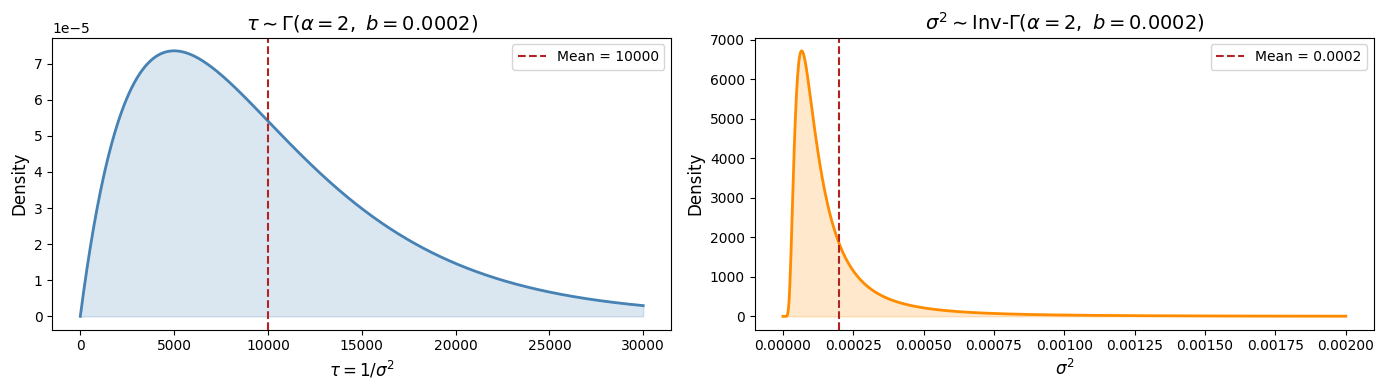

In [10]:
# tau = 1/sigma^2 ~ Gamma(shape=alpha, rate=b), so sigma^2 ~ InvGamma(shape=alpha, scale=b)
alpha, rate = 2, 0.0002
scale = 1 / rate  # scipy gamma uses scale = 1/rate

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Gamma (tau = 1/sigma^2) ---
x_gamma = np.linspace(0, 30000, 1000)
pdf_gamma = stats.gamma.pdf(x_gamma, a=alpha, scale=scale)
gamma_mean = alpha / rate  # E[tau] = alpha / rate = 10000
axes[0].plot(x_gamma, pdf_gamma, color='steelblue', linewidth=2)
axes[0].fill_between(x_gamma, pdf_gamma, alpha=0.2, color='steelblue')
axes[0].axvline(gamma_mean, color='firebrick', linestyle='--', label=f'Mean = {gamma_mean:.0f}')
axes[0].set_title(r'$\tau \sim \Gamma(\alpha=2,\ b=0.0002)$', fontsize=14)
axes[0].set_xlabel(r'$\tau = 1/\sigma^2$', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].legend()

# --- Inverse Gamma (sigma^2 = 1/tau) ---
# If tau ~ Gamma(alpha, rate=b), then 1/tau ~ InvGamma(alpha, scale=b)
# E[sigma^2] = b / (alpha - 1)  ≠  1 / E[tau] = rate/alpha
x_invgamma = np.linspace(0, 0.002, 1000)
pdf_invgamma = stats.invgamma.pdf(x_invgamma, a=alpha, scale=rate)  # scale = b = rate
inv_mean = rate / (alpha - 1)  # = 0.0002 / 1 = 0.0002
axes[1].plot(x_invgamma, pdf_invgamma, color='darkorange', linewidth=2)
axes[1].fill_between(x_invgamma, pdf_invgamma, alpha=0.2, color='darkorange')
axes[1].axvline(inv_mean, color='firebrick', linestyle='--', label=f'Mean = {inv_mean:.4f}')
axes[1].set_title(r'$\sigma^2 \sim \mathrm{Inv\text{-}}\Gamma(\alpha=2,\ b=0.0002)$', fontsize=14)
axes[1].set_xlabel(r'$\sigma^2$', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Let's proceed with deriving the posterior mean. Bayes' Theorem gives us:
$$ f(\tau | X) = \frac{f(X | \tau)f(\tau)}{f(X)} $$

We already have $f(\tau)$ from above. To find $f(X | \tau)$, we substitute $\theta = \frac{1}{\tau}$ into our Likelihood function from the MLE calculation:

$$f(X | \tau) = \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{X_i^2\tau}{2}\right)}$$

And so

$$ 
\begin{align*}
f(\tau | X) &= \frac{\left( \prod_{i=1}^n \sqrt{\frac{\tau}{2\pi}} e^ {\left(-\frac{X_i^2\tau}{2}\right)} \right)   \left( 4 \cdot 10^{-8} \cdot \tau e^ {- 0.0002 \tau} \right)}{f(X)} \\
&= K \tau ^{n/2} \cdot e^{-\frac{\tau}{2} \sum X_i^2} \cdot \tau e ^{-0.0002 \tau}  & \text{where K is some constant}\\
&= K \tau ^ {n/2 + 1} \cdot e^ {-\tau \left( \frac 12 \sum X_i^2 + 0.0002\right)} \\
&= \Gamma (\alpha = \frac{n}{2} + 2, \beta = \frac 12 \sum X_i^2 + 0.0002) \\
&= \Gamma (\alpha = \frac{n}{2} + \alpha_0, \beta = \frac 12 \sum X_i^2 + \beta_0) & \text{for general prior } \alpha_0, \beta_0
\end{align*}
$$
since we know the posterior will also be a Gamma distribution.

Finally, to get the posterior mean, we have
$$ \hat \theta 
= \frac{\frac 12 \sum X_i^2 + 0.0002}{\frac{n}{2} + 2 - 1} 
= \frac{\sum X_i^2 + 0.0004}{n + 2} $$

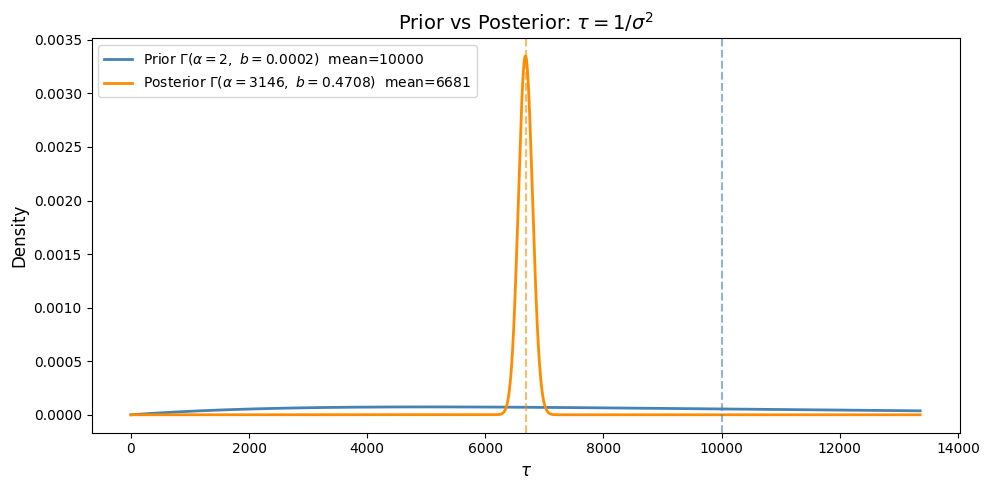

In [22]:
x = log_returns.values.squeeze()
n = len(x)
alpha_0, b_0 = 2, 0.0002

# Prior: tau ~ Gamma(alpha_0, rate=b_0)
# Posterior: tau | X ~ Gamma(alpha_0 + n/2, rate=b_0 + 0.5*sum(x^2))
a_prior, b_prior = alpha_0, b_0
a_post  = alpha_0 + n / 2
b_post  = b_0 + 0.5 * np.sum(x**2)

prior_mean = a_prior / b_prior
post_mean  = a_post  / b_post

# Use a shared x-axis around the posterior (prior is far left and very spread out)
x_range = np.linspace(0, 2 * post_mean, 2000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_range, stats.gamma.pdf(x_range, a=a_prior, scale=1/b_prior),
        color='steelblue', linewidth=2, label=f'Prior $\\Gamma(\\alpha={a_prior:.0f},\\ b={b_prior})$  mean={prior_mean:.0f}')
ax.plot(x_range, stats.gamma.pdf(x_range, a=a_post,  scale=1/b_post),
        color='darkorange', linewidth=2, label=f'Posterior $\\Gamma(\\alpha={a_post:.0f},\\ b={b_post:.4f})$  mean={post_mean:.0f}')
ax.axvline(prior_mean, color='steelblue', linestyle='--', alpha=0.6)
ax.axvline(post_mean,  color='darkorange', linestyle='--', alpha=0.6)

ax.set_title(r'Prior vs Posterior: $\tau = 1/\sigma^2$', fontsize=14)
ax.set_xlabel(r'$\tau$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Bringing in the Data

We have estimators:

Frequentist: 
$$ \hat \theta = \frac{1}{n} \sum X_i^2$$
Bayesian: 
$$ \hat \theta = \frac{\sum X_i^2 + 0.0004}{n + 2} = \frac{\sum X_i^2 + 2\beta_0}{n + 2(\alpha_0 - 1)} $$

In [17]:
def maximum_likelihood(log_returns):
    return np.mean(log_returns ** 2)

def posterior_mean(log_returns, alpha = 2.0, beta = 0.0002):
    return (np.sum(log_returns ** 2) + 2 * beta) / (len(log_returns) + 2 * (alpha - 1))

print(f"Maximum likelihood: {maximum_likelihood(log_returns):.8f}")
print(f"Posterior mean: {posterior_mean(log_returns):.8f}")
print(f"Difference: {maximum_likelihood(log_returns) - posterior_mean(log_returns):.8f}")

Maximum likelihood: 0.00014972
Posterior mean: 0.00014973
Difference: -0.00000002


The MLE is almost identical to the posterior mean, with posterior mean being slightly higher, biased towards the prior (0.0002). This makes sense! We didn't cover this in class, but I'm sure there's some theorem somewhere that says that as $n$ goes to infinity, the posterior mean estimate will equal the MLE, regardless of prior. Actually, here's a quick proof for our specific estimators.
$$\lim_{n \rightarrow \infty} \hat{\theta}_{\text{Bayes}} = \lim_{n \rightarrow \infty} \frac{\sum X_i^2 + 2\beta_0}{n + 2(\alpha_0 - 1)} = \lim_{n \rightarrow \infty} \frac{\frac{1}{n}\sum X_i^2 + \frac{2\beta_0}{n}}{1 + \frac{2(\alpha_0-1)}{n}} = \frac{\frac{1}{n}\sum X_i^2}{1} = \hat{\theta}_{\text{MLE}}$$

Let's now see how these estimators look on the data.

MLE variance:        0.000150  (std=0.0122)
Posterior mean var:  0.000150  (std=0.0122)


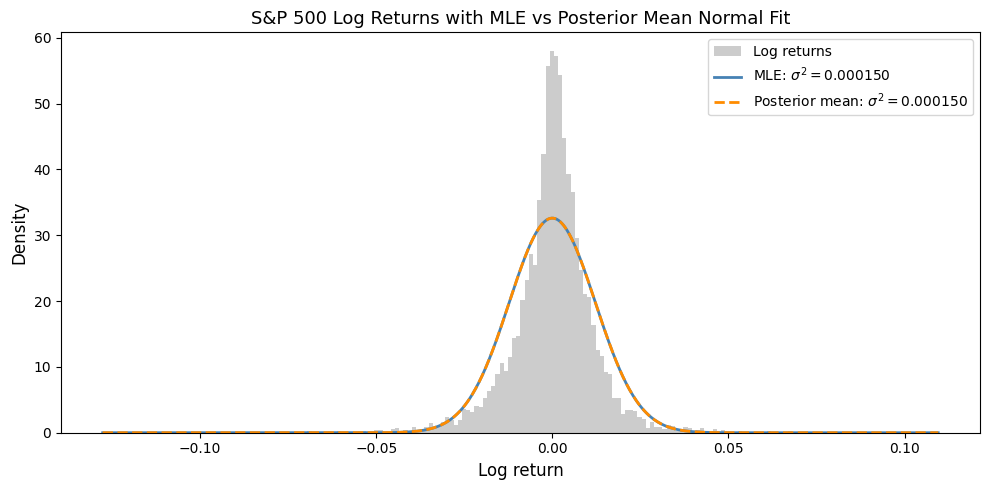

In [20]:
n = len(log_returns)

var_mle = maximum_likelihood(x)
var_post = posterior_mean(x)

print(f"MLE variance:        {var_mle:.6f}  (std={np.sqrt(var_mle):.4f})")
print(f"Posterior mean var:  {var_post:.6f}  (std={np.sqrt(var_post):.4f})")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_returns, bins=200, density=True, color='gray', alpha=0.4, label='Log returns')

x_range = np.linspace(log_returns.min(), log_returns.max(), 1000)
ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(var_mle)),
        color='steelblue', linewidth=2, label=f'MLE: $\\sigma^2={var_mle:.6f}$')
ax.plot(x_range, stats.norm.pdf(x_range, 0, np.sqrt(var_post)),
        color='darkorange', linewidth=2, linestyle='--', label=f'Posterior mean: $\\sigma^2={var_post:.6f}$')

ax.set_title('S&P 500 Log Returns with MLE vs Posterior Mean Normal Fit', fontsize=13)
ax.set_xlabel('Log return', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

### Bias/Variance Analysis

Replicating the simulation in `mle_gamma.qmd`: we simulate from a Normal distribution with $\mu = 0$ and $\sigma^2 = \hat\theta_{\text{MLE}}$, using $n = 100$ to make the difference visible.

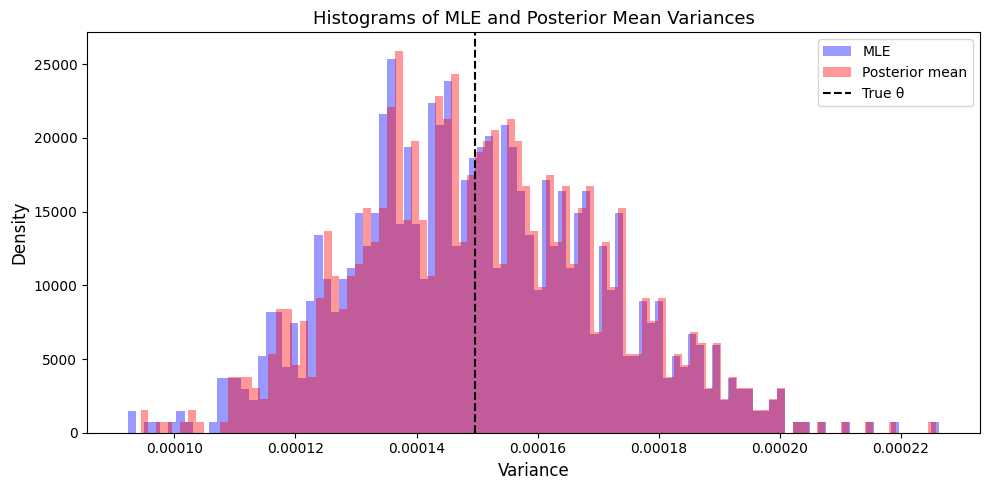

MLE bias:      0.000000
Bayes bias:    0.000001
MLE variance:  4.48e-10
Bayes variance:4.31e-10


In [43]:
true_theta = maximum_likelihood(log_returns)
num_simulations = 1000
num_samples = 100

mle_variances = []
pm_variances = []

for _ in range(num_simulations):
    simulated_log_returns = np.random.normal(0, np.sqrt(true_theta), num_samples)
    mle_variances.append(maximum_likelihood(simulated_log_returns))
    pm_variances.append(posterior_mean(simulated_log_returns))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mle_variances, bins=100, density=True, color='blue', alpha=0.4, label='MLE')
ax.hist(pm_variances, bins=100, density=True, color='red', alpha=0.4, label='Posterior mean')
ax.axvline(true_theta, color='black', linestyle='--', label='True θ')

ax.set_title('Histograms of MLE and Posterior Mean Variances', fontsize=13)
ax.set_xlabel('Variance', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"MLE bias:      {np.mean(mle_variances) - true_theta:.6f}")
print(f"Bayes bias:    {np.mean(pm_variances) - true_theta:.6f}")
print(f"MLE variance:  {np.var(mle_variances):.2e}")
print(f"Bayes variance:{np.var(pm_variances):.2e}")

Because we use MLE estimate as the true theta, MLE is pretty essentially unbiased. Bayes has a very tiny positive bias, as it's pulled towards the prior. 

Bayes' variance is slightly less, which is the tradeoff we get for an increase in bias.

Now, let's generalize this to many different n, to quantify the bias-variance tradeoff.

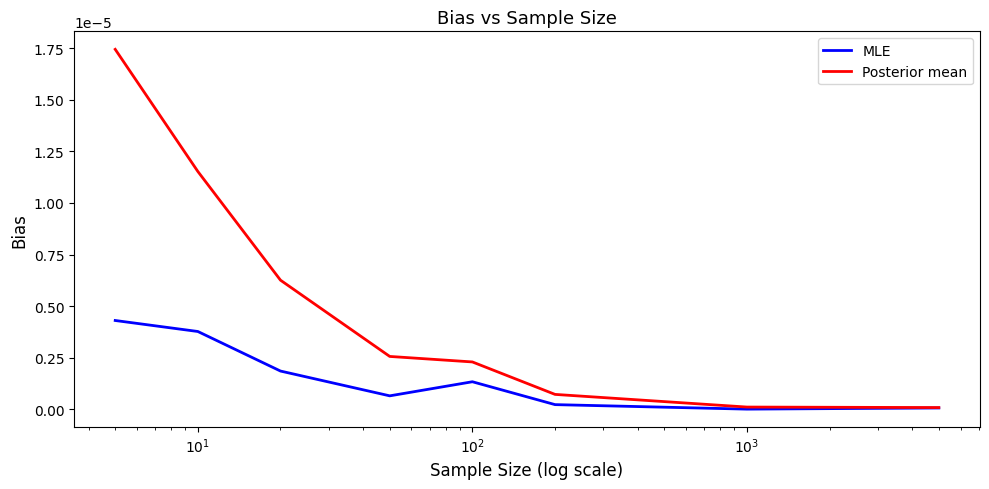

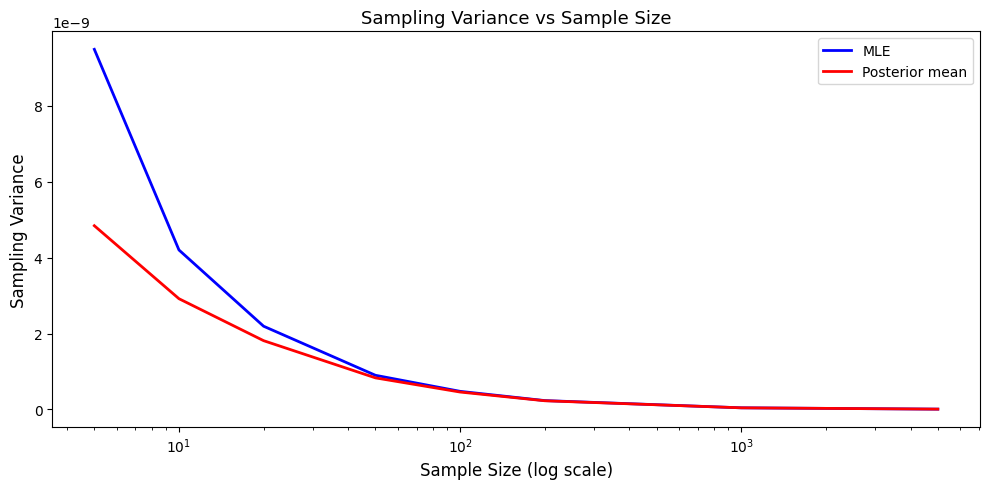

In [46]:
n_list = [5, 10, 20, 50, 100, 200, 1000, 5000]
num_simulations = 1000
true_theta = maximum_likelihood(log_returns)

mle_biases = []
mle_sampling_var = []
pm_biases = []
pm_sampling_var = []

for n_ in n_list:
    mle_variances = []
    pm_variances = []
    for _ in range(num_simulations):
        simulated_log_returns = np.random.normal(0, np.sqrt(true_theta), n_)
        mle_variances.append(maximum_likelihood(simulated_log_returns))
        pm_variances.append(posterior_mean(simulated_log_returns))

    mle_biases.append(np.mean(mle_variances) - true_theta)
    mle_sampling_var.append(np.var(mle_variances))
    pm_biases.append(np.mean(pm_variances) - true_theta)
    pm_sampling_var.append(np.var(pm_variances))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_list, mle_biases, color='blue', linewidth=2, label='MLE')
ax.plot(n_list, pm_biases, color='red', linewidth=2, label='Posterior mean')
ax.set_xscale('log')
ax.set_title('Bias vs Sample Size', fontsize=13)
ax.set_xlabel('Sample Size (log scale)', fontsize=12)
ax.set_ylabel('Bias', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_list, mle_sampling_var, color='blue', linewidth=2, label='MLE')
ax.plot(n_list, pm_sampling_var, color='red', linewidth=2, label='Posterior mean')
ax.set_xscale('log')
ax.set_title('Sampling Variance vs Sample Size', fontsize=13)
ax.set_xlabel('Sample Size (log scale)', fontsize=12)
ax.set_ylabel('Sampling Variance', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()